In [1]:
from reflect.components.flow_world_model.dynamic_model import DynamicFlowModel, DynamicAttentionalFlowModel
from reflect.components.flow_world_model.world_model_actor import WorldModelActor
from reflect.components.flow_world_model.world_model import WorldModel
from reflect.data.loader import EnvDataLoader
from reflect.components.models.actor import Actor

from tqdm import tqdm
from livelossplot import PlotLosses
import gymnasium as gym
from dataclasses import asdict
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim

/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [2]:
# class SimpleActor(Actor):
#     def __init__(self, input_dim, output_dim, bound, num_layers, hidden_dim):
#         super().__init__(input_dim, output_dim, bound, num_layers, hidden_dim)
#         self.thing = None

#     def __call__(self, x, deterministic=False):
#         if self.thing is None:
#             if torch.rand(1) > 0.5:
#                 self.thing = torch.tensor([-1.0])
#             else:
#                 self.thing = torch.tensor([1.0])
#         return self.thing

#     def reset(self):
#         self.thing = None
#         super().reset()


env = gym.make('Pendulum-v1')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

actor = Actor(
    input_dim=state_dim,
    output_dim=action_dim,
    bound=env.action_space.high,
    num_layers=3,
    hidden_dim=256,
)

world_model_actor = WorldModelActor(
    actor=actor,
)

env_data_loader = EnvDataLoader(
    num_time_steps=10,
    state_shape=(state_dim,),
    policy=world_model_actor,
    env=env,
    use_imgs_as_states=False,
)


In [94]:
env.observation_space.shape[0]

3

In [3]:
for _ in tqdm(range(10)):
    env_data_loader.perform_rollout()

100%|██████████| 10/10 [00:01<00:00,  7.07it/s]


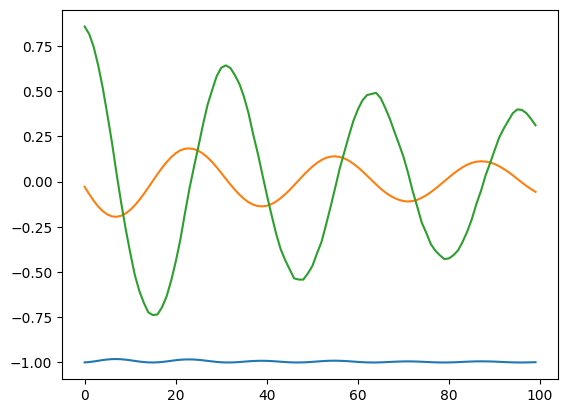

In [4]:
import matplotlib.pyplot as plt
plt.plot(env_data_loader.state_buffer[3][:, 0])
plt.plot(env_data_loader.state_buffer[3][:, 1])
plt.plot(env_data_loader.state_buffer[3][:, 2])
plt.show()

In [5]:
b_inds, t_inds, s, a, r, d = env_data_loader.sample(
    batch_size=16,
    num_time_steps=3
)

print(s.shape)
print(a.shape)
print(r.shape)
print(d.shape)


torch.Size([16, 3, 3])
torch.Size([16, 3, 1])
torch.Size([16, 3, 1])
torch.Size([16, 3, 1])


In [6]:
state_dim = 3+1+1
action_dim = 1

dynamic_model = DynamicFlowModel(
    input_dim=state_dim,
    conditioning_dim=3*(state_dim + action_dim),
    output_dim=state_dim,
    time_embed_dim=16,
    hidden_dim=128,
    depth=2,
    use_layer_norm=True,
    num_positions=3,
)

# dynamic_model = DynamicAttentionalFlowModel(
#     input_dim=state_dim,
#     conditioning_dim=state_dim + action_dim,
#     output_dim=state_dim,
#     num_heads=4,
#     hidden_dim=256,
#     depth=2,
#     use_layer_norm=True,
#     num_positions=3,
# )

In [7]:
from reflect.utils import (
    AdamOptim,
)

optimizer = optim.Adam(dynamic_model.parameters(), lr=1e-3)

In [8]:
time_coeff = 0

In [9]:
def _update(
        flow_model: DynamicFlowModel,
        o: torch.Tensor,
        a: torch.Tensor,
        r: torch.Tensor,
        d: torch.Tensor,
    ):

    optimizer.zero_grad()
    x_cond = torch.cat([o[:, 0:3], r[:, 0:3], d[:, 0:3], a[:, 0:3]], dim=-1)
    x_real = torch.cat([o[:, [-1]], r[:, [-1]], d[:, [-1]]], dim=-1)
    x_last = torch.cat([o[:, [-2]], r[:, [-2]], d[:, [-2]]], dim=-1)
    b, l, d = x_real.shape
    t = torch.rand(b, 1, 1, device=x_real.device)
    x_sample = torch.randn_like(x_last)*0.05 + x_last
    x_interp = (1 - t) * x_sample + t * x_real
    v = (x_real - x_sample).reshape(b, d)
    u = dynamic_model.forward(x_cond, x_interp, t)
    u_loss = ((u - v) ** 2).mean()
    loss = u_loss
    loss.backward()
    optimizer.step()

    rel_err = (
        (u - v).norm(dim=1)
        / (v.norm(dim=1) + 1e-4)
    ).mean()
    return {
        'flow_loss': u_loss.item(),
        'rel_err': rel_err.item()
    }

In [10]:
a = torch.tensor([1,2,3,4])
print(a[0:3], a[-1:], a[[-2]])

tensor([1, 2, 3]) tensor([4]) tensor([3])


In [11]:
_, _, o, a, r, d = env_data_loader.sample(
    batch_size=256,
    num_time_steps=4
)
losses = _update(dynamic_model, o, a, r, d)

In [12]:
plot_losses = PlotLosses(
  groups={
    'flow_loss': ['flow_loss'],
    'rel_err': ['rel_err'],
  },
)

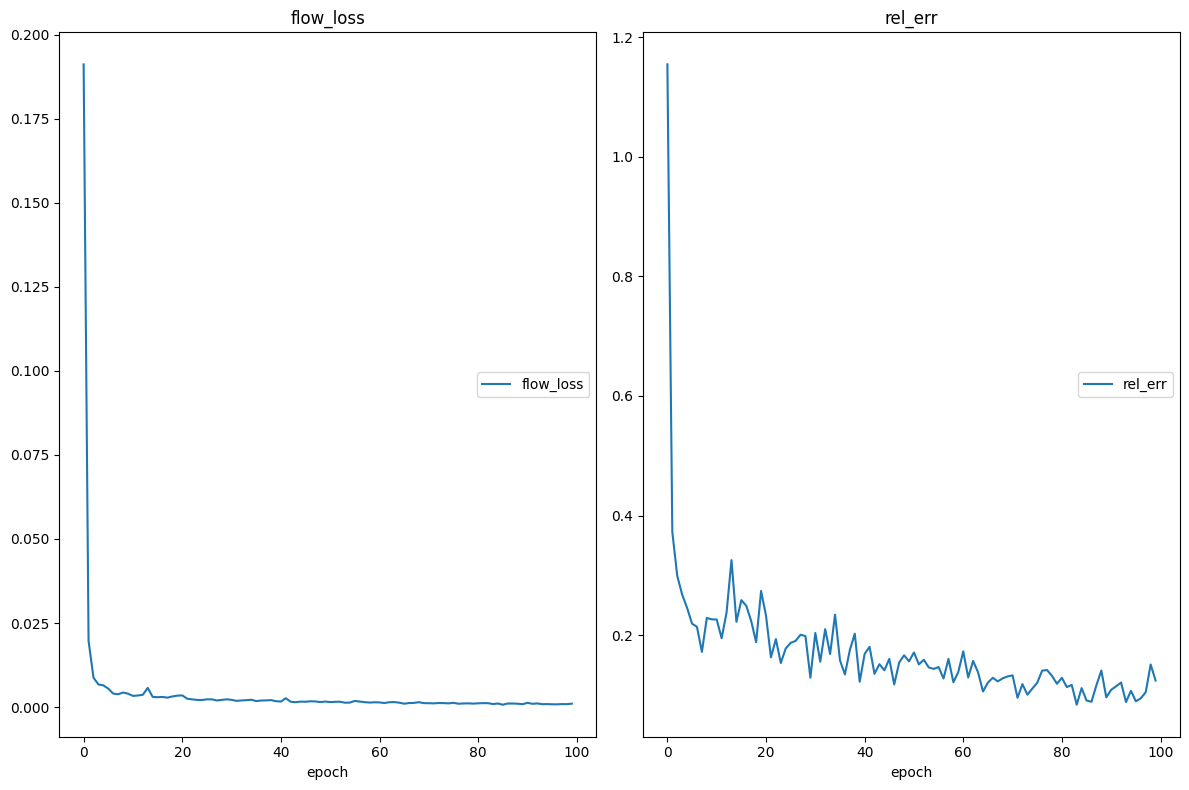

flow_loss
	flow_loss        	 (min:    0.001, max:    0.191, cur:    0.001)
rel_err
	rel_err          	 (min:    0.084, max:    1.154, cur:    0.124)


In [13]:
total_loss = 0
total_rel_err = 0
update_every = 100
for epoch in range(10_000):
    env_data_loader.perform_rollout()
    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=256,
        num_time_steps=4
    )
    losses = _update(dynamic_model, o, a, r, d)
    total_loss += losses['flow_loss']
    total_rel_err += losses['rel_err']
    if epoch % update_every == 0:        
        # print(f"Epoch {epoch:03d} | loss = {total_loss / update_every:.4f} | rel_err = {total_rel_err / update_every:.4f}")
        plot_losses.update(losses)
        plot_losses.send()
        total_loss = 0
        total_rel_err = 0


In [14]:
import matplotlib.pyplot as plt

In [119]:
def _step(
        flow_model: DynamicFlowModel,
        x_cond: torch.Tensor,
        x: torch.Tensor,
        t: torch.Tensor,
        delta: float,
        step_type: str = 'euler',
    ):    
    if step_type == 'euler':
        u = flow_model.forward(x_cond, x, t)
        x_next = x + u * delta
        return x_next, t + delta
    else:
        raise ValueError(f'Invalid step type: {step_type}')

In [127]:
# seems to work with t=1? WTF?

In [128]:
def get_next_step(o, a, r, d, num_steps=100):
    x_cond = torch.cat([o[:, 0:3], r[:, 0:3], d[:, 0:3], a[:, 0:3]], dim=-1)
    t = torch.ones(1, 1, 1, device=x_cond.device)
    i_dim = o.shape[-1] + r.shape[-1] + d.shape[-1]
    i = torch.cat([o[:, [-1]], r[:, [-1]], d[:, [-1]]], dim=-1) 
    # i = i + torch.randn_like(i)*0.05
    trajectory = torch.zeros(num_steps, 1, i_dim)
    delta = 1/num_steps
    step_type = 'euler'
    for step in range(num_steps):
        trajectory[step] = i
        i, t = _step(dynamic_model, x_cond, i, t, delta, step_type)
    trajectory[step] = i

    return trajectory.detach()

In [131]:
def get_imagined_rollout(o, a, r, d, num_steps=100, rollout_length=100):
    img_o = torch.zeros(1, rollout_length, o.shape[-1])
    img_r = torch.zeros(1, rollout_length, 1)
    img_d = torch.zeros(1, rollout_length, 1)
    img_a = torch.zeros(1, rollout_length, a.shape[-1])
    img_o[:, 0:3, :] = o
    img_a[:, 0:3, :] = a
    img_r[:, 0:3, :] = r
    img_d[:, 0:3, :] = d
    for i in tqdm(range(3, rollout_length)):
        trajectory = get_next_step(img_o[:, i-3:i, :], img_a[:, i-3:i, :], img_r[:, i-3:i, :], img_d[:, i-3:i, :], num_steps)
        new_o = trajectory[-1, :, :3]
        new_r = trajectory[-1, :, 3:4]
        new_d = trajectory[-1, :, 4:5]
        img_o[:, i, :] = new_o
        img_r[:, i, :] = new_r
        img_d[:, i, :] = new_d
        action = actor(new_o, deterministic=True)
        img_a[:, i, :] = action
    return img_o, img_a, img_r, img_d



100%|██████████| 97/97 [00:01<00:00, 94.20it/s]


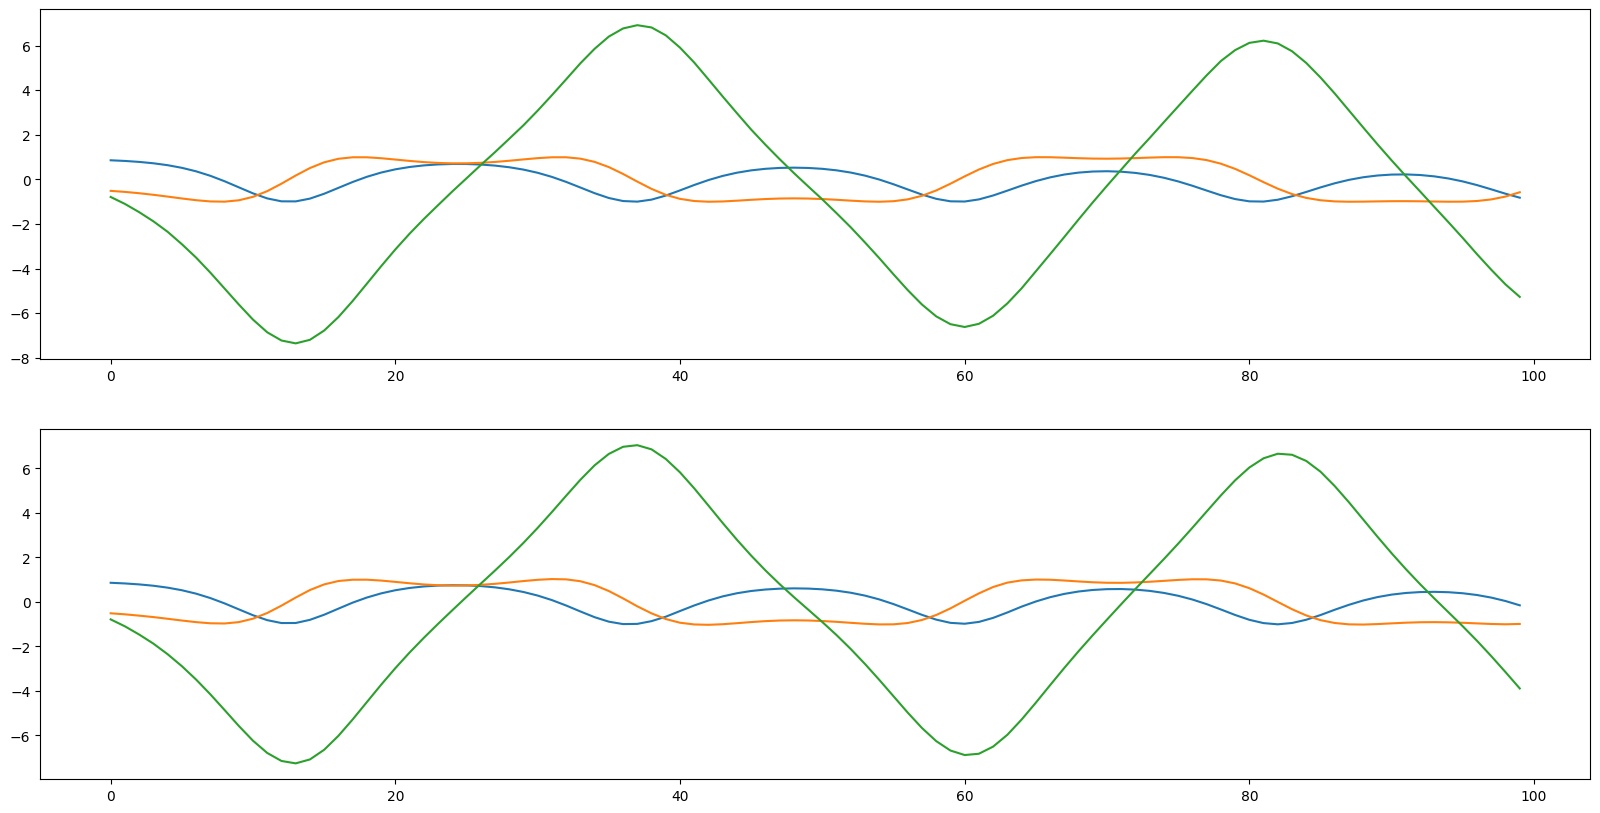

In [130]:
import matplotlib.pyplot as plt
import random

traj_i = random.randint(0, len(env_data_loader.state_buffer) - 1)

o = env_data_loader.state_buffer[traj_i][None, :, :]
a = env_data_loader.action_buffer[traj_i][None, :, :]
r = env_data_loader.reward_buffer[traj_i][None, :, None]
d = env_data_loader.done_buffer[traj_i][None, :, None]

img_o, img_a, img_r, img_d = get_imagined_rollout(o[:, :3], a[:, :3], r[:, :3], d[:, :3], num_steps=20)

fig, axs = plt.subplots(nrows=2, figsize=(20, 10))
axs[0].plot(o[0, :, 0])
axs[0].plot(o[0, :, 1])
axs[0].plot(o[0, :, 2])
axs[1].plot(img_o[0, :, 0])
axs[1].plot(img_o[0, :, 1])
axs[1].plot(img_o[0, :, 2])
plt.show()